# Policy rollouts

## Imports & global configurations

In [1]:
import sys
sys.path.append("..")

from source.policy import HeuristicPolicy, NeuralPolicy
from source.simulation import rollout_trajectory, sample_initial_state
from source.stochastic_processes import make_price_function
from source.system import SystemParams
from source.utils import read_csv
from source.plotting import *
from source.diagnostics import check_energy_balance

import torch

import matplotlib.pyplot as plt
plt.style.use("../styles/paper.mplstyle")

In [2]:
global_seed = 123

device = torch.device("cpu")
batch_size = 1000

params = SystemParams()

S0 = sample_initial_state(
    batch_size=batch_size,
    params=params,
    device=device,
    seed=global_seed
)

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]

results = {}

## Heuristic Policy

In [3]:
next_price_fn = make_price_function(
    endog_history=price_history,
    future_endog=future_price,
    params=params
)

policy = HeuristicPolicy()

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_fn,
    lambda_cost=0.0,
    alpha_grid=0.0,
    stochastic=True,
    seed=global_seed,
    device=device
)

results["heuristic"] = history

In [4]:
check_energy_balance(history, params.dt)

{'max_abs_error': 0.0,
 'mean_abs_error': 0.0,
 'mean_Ub': 34.942161560058594,
 'max_Ub': 432.0}

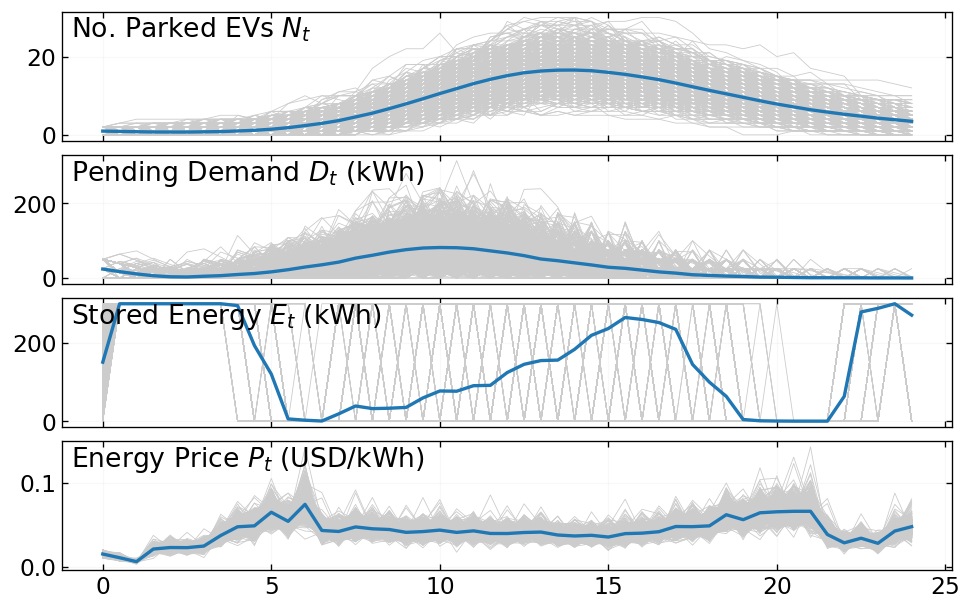

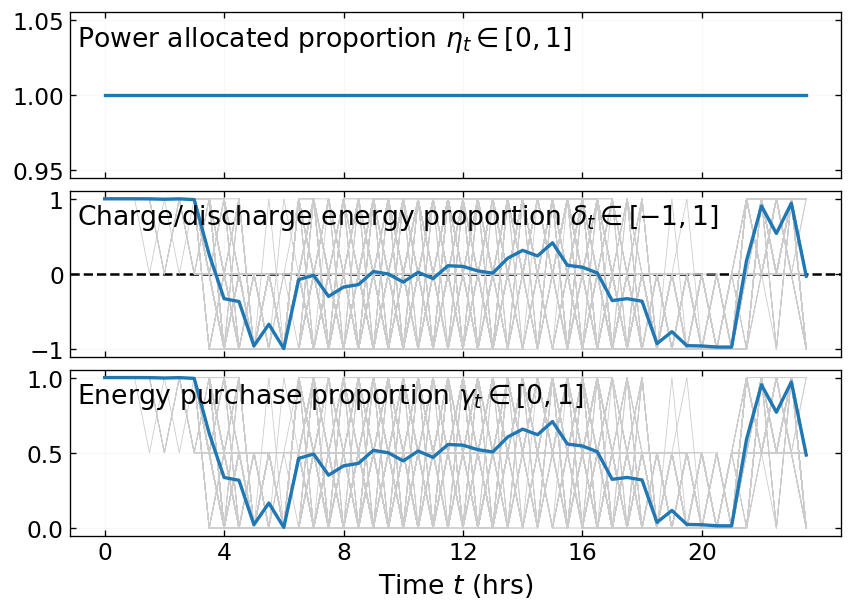

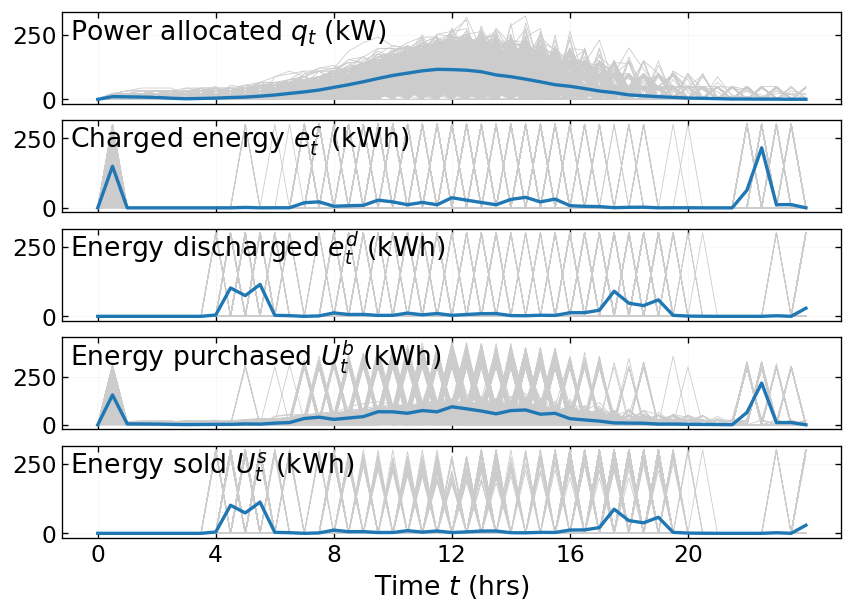

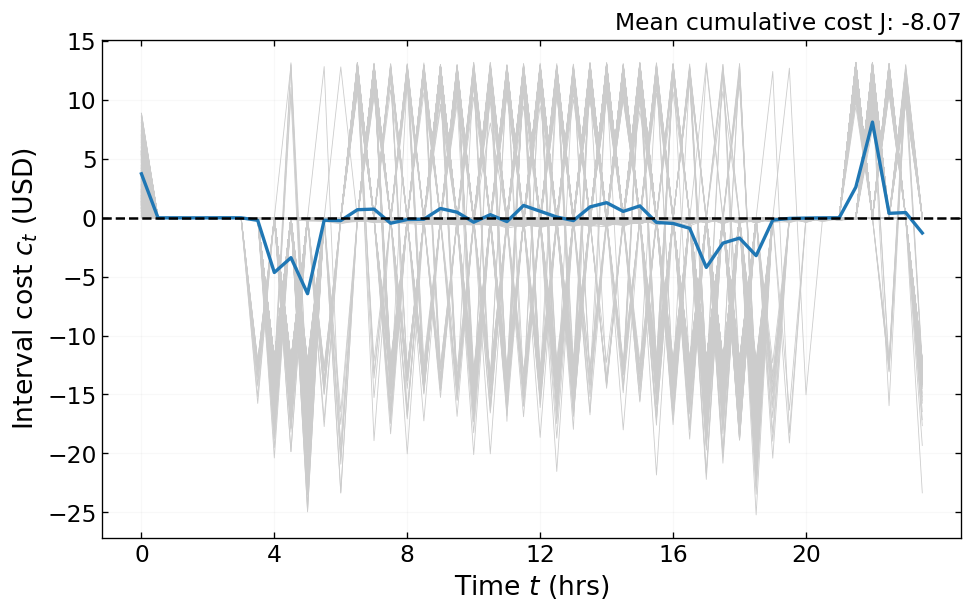

In [5]:
plot_state_trajectories(
    history, save_path="../figures/heuristic_policy/states.pdf"
)
plot_control_trajectories(
    history, save_path="../figures/heuristic_policy/controls.pdf"
)
plot_endogenous_trajectories(
    history, save_path="../figures/heuristic_policy/endogenous.pdf"
)
plot_cost_trajectories(
    history, save_path="../figures/heuristic_policy/cost.pdf"
)

## Untrained Neural Policy 

In [6]:
from pathlib import Path
import torch

In [7]:
next_price_fn = make_price_function(
    endog_history=price_history,
    future_endog=future_price,
    params=params
)

torch.manual_seed(global_seed + 26)
policy = NeuralPolicy()

checkpoint_dir = Path("../checkpoints/policies")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "seed": global_seed + 26,
        "state_dict": policy.state_dict(),
        "description": "Fixed untrained policy baseline"
    },
    checkpoint_dir / "untrained_policy.pt"
)

checkpoint = torch.load(
    "../checkpoints/policies/untrained_policy.pt",
    map_location=device
)

policy = NeuralPolicy().to(device)
policy.load_state_dict(checkpoint["state_dict"])
policy.eval()


history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_fn,
    lambda_cost=0.0,
    alpha_grid=0.0,
    stochastic=True,
    seed=global_seed,
    device=device
)

results["untrained"] = history

In [8]:
check_energy_balance(history, params.dt)

{'max_abs_error': 1.9073486328125e-06,
 'mean_abs_error': 1.9729546885116633e-09,
 'mean_Ub': 16.503063201904297,
 'max_Ub': 136.29330444335938}

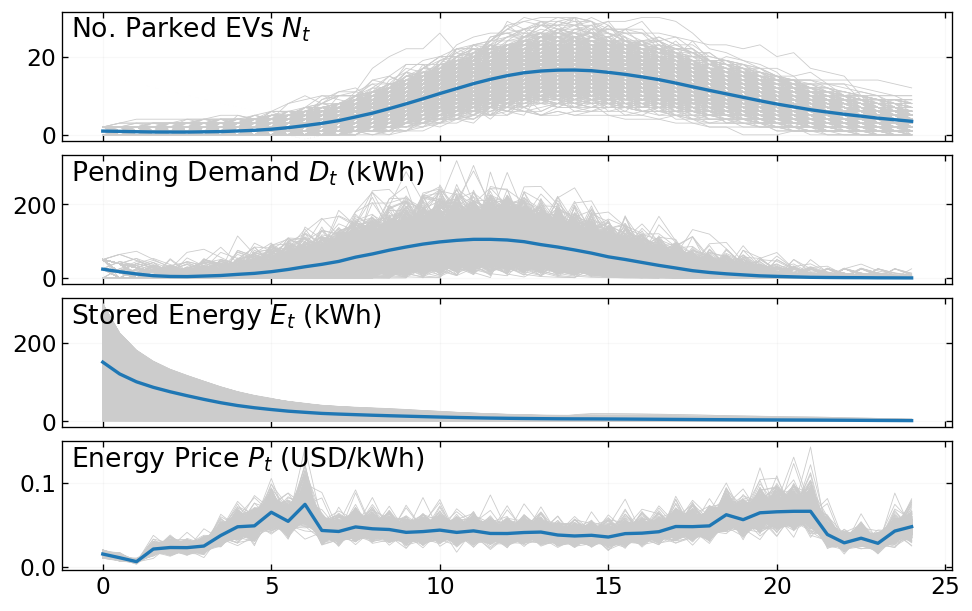

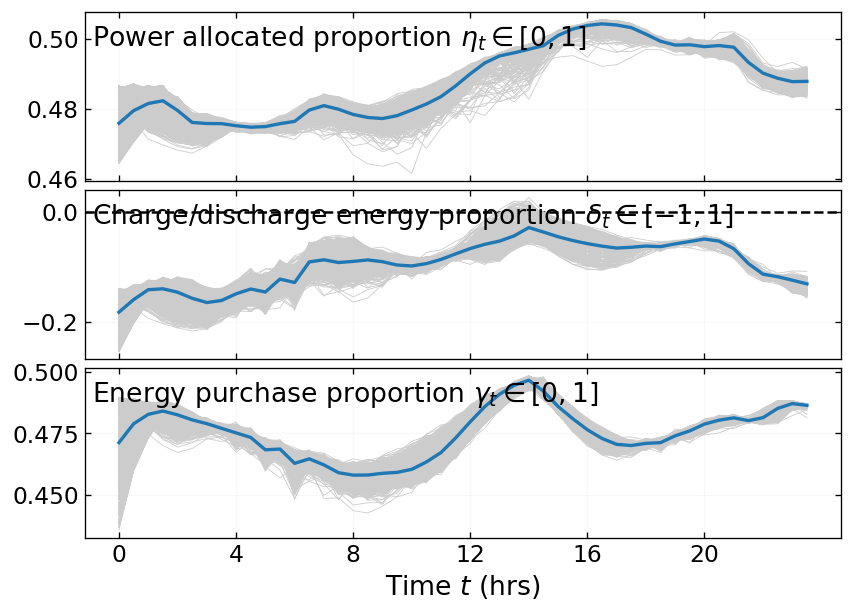

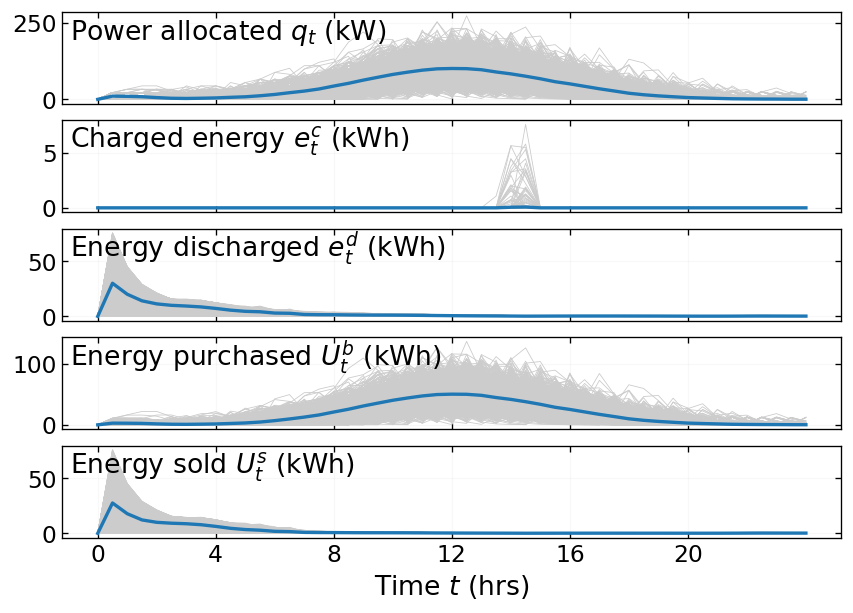

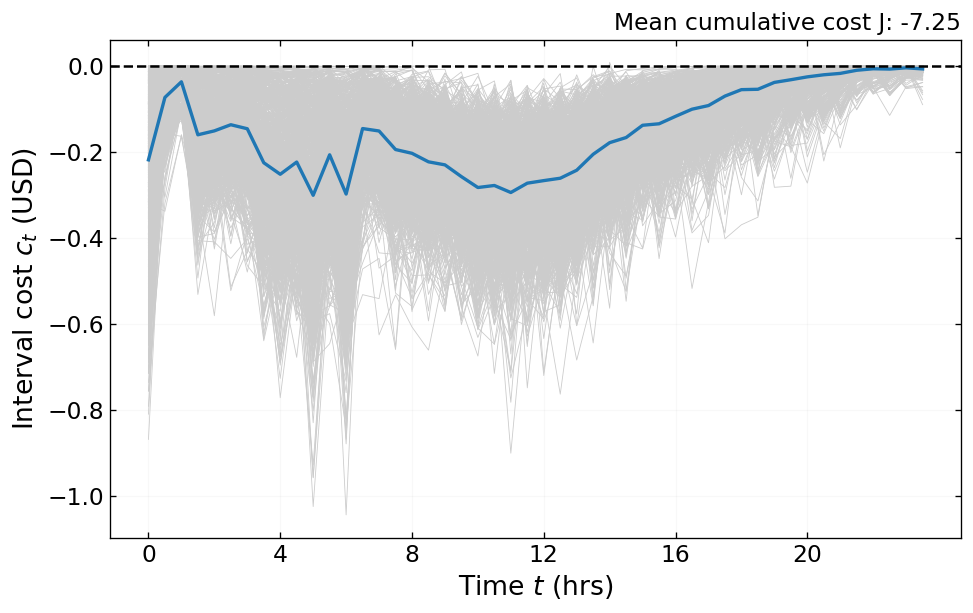

In [9]:
plot_state_trajectories(
    history, save_path="../figures/untrained_policy/states.pdf"
)
plot_control_trajectories(
    history, save_path="../figures/untrained_policy/controls.pdf"
)
plot_endogenous_trajectories(
    history, save_path="../figures/untrained_policy/endogenous.pdf"
)
plot_cost_trajectories(
    history, save_path="../figures/untrained_policy/cost.pdf"
)

## Trained Neural Policy

In [10]:
from source.training import train_net

EPOCHS = 1000

S0_single = torch.tensor([[0., 0., 100., 0.01]], device=device)

policy = NeuralPolicy().to(device)

optimizer = torch.optim.AdamW(
    policy.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

res = train_net(
    policy=policy,
    optimizer=optimizer,
    device=device,
    params=params,
    S0_single=S0_single,
    endog_history=price_history,
    future_endog=future_price,
    epochs=EPOCHS,
    batch_size=batch_size,
    verbose=True,
    seed_base=global_seed
)

[050] J_train=-10.9405 | J_eval(det)=-11.3349
[100] J_train=-13.6380 | J_eval(det)=-14.0063
[150] J_train=-14.9533 | J_eval(det)=-15.1659
[200] J_train=-15.6186 | J_eval(det)=-15.7873
[250] J_train=-17.0085 | J_eval(det)=-16.7110
[300] J_train=-20.2704 | J_eval(det)=-19.3254
[350] J_train=-22.0421 | J_eval(det)=-20.5380
[400] J_train=-22.9784 | J_eval(det)=-20.8345
[450] J_train=-23.7422 | J_eval(det)=-21.1384
[500] J_train=-24.4559 | J_eval(det)=-21.3258
[550] J_train=-24.9431 | J_eval(det)=-21.5491
[600] J_train=-25.4821 | J_eval(det)=-21.6835
[650] J_train=-26.2100 | J_eval(det)=-21.8536
[700] J_train=-26.4899 | J_eval(det)=-22.0227
[750] J_train=-26.5313 | J_eval(det)=-22.1618
[800] J_train=-26.5101 | J_eval(det)=-22.2484
[850] J_train=-26.6524 | J_eval(det)=-22.3451
[900] J_train=-26.9655 | J_eval(det)=-22.4628
[950] J_train=-26.7588 | J_eval(det)=-22.4292
[1000] J_train=-26.9605 | J_eval(det)=-22.5469

Training ready in 480.9s. Epoch: 996. Best J=-27.4516


In [11]:
from pathlib import Path
import torch

checkpoint_dir = Path("../checkpoints/policies")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "epochs": EPOCHS,
        "seed_base": global_seed,
        "batch_size": batch_size,
        "state_dict": policy.state_dict(),
    },
    checkpoint_dir / "trained_policy.pt"
)

In [ ]:
checkpoint = torch.load(
    "../checkpoints/policies/trained_policy.pt",
    map_location=device
)

policy = NeuralPolicy().to(device)
policy.load_state_dict(checkpoint["state_dict"])
policy.eval()

next_price_fn = make_price_function(price_history, future_price, params)

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_fn,
    stochastic=True,
    alpha_grid=0.0,
    lambda_cost=0.0,
    seed=global_seed,
    device=device,
)

results["trained"] = history

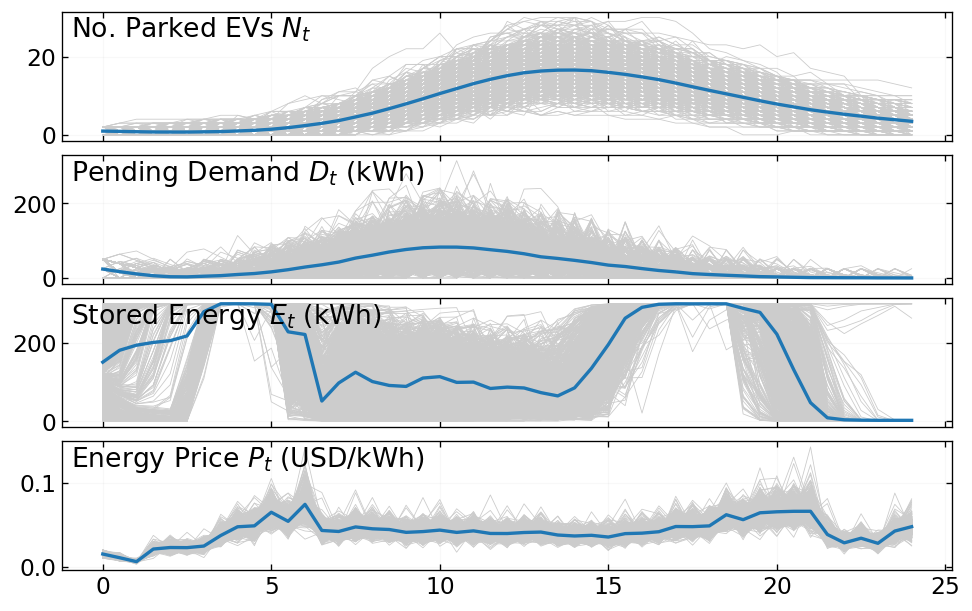

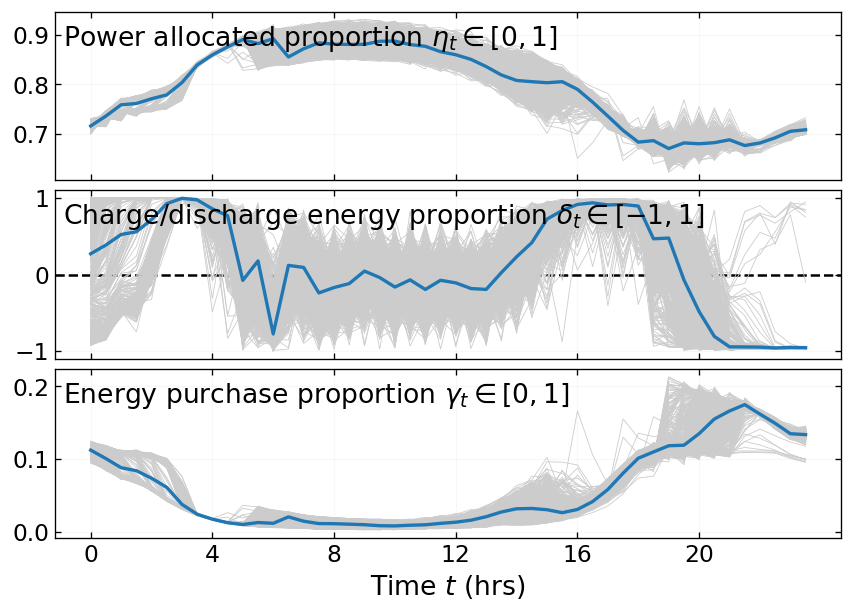

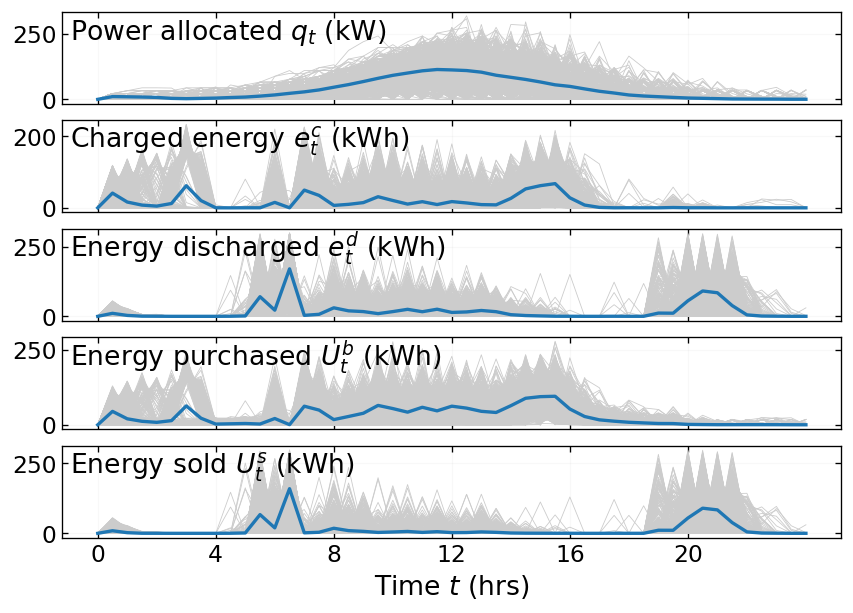

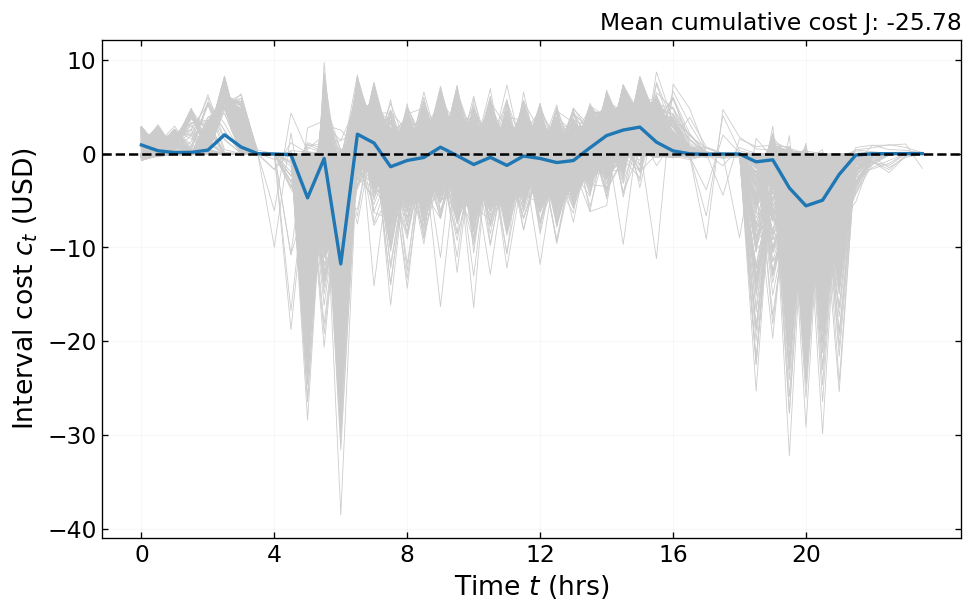

In [13]:
plot_state_trajectories(
    history, save_path="../figures/trained_policy/states.pdf"
)
plot_control_trajectories(
    history, save_path="../figures/trained_policy/controls.pdf"
)
plot_endogenous_trajectories(
    history, save_path="../figures/trained_policy/endogenous.pdf"
)
plot_cost_trajectories(
    history, save_path="../figures/trained_policy/cost.pdf"
)

## Stochastic Scenario Verification

In [14]:
print("\n" + "="*60)
print("ARRIVALS (arrival)")
print("="*60)

same = torch.allclose(
    results["untrained"]["arrival"],
    results["heuristic"]["arrival"]
)
max_diff = (
    results["untrained"]["arrival"]
    - results["heuristic"]["arrival"]
).abs().max().item()

print(f"Untrained vs heuristic : {same}")
print(f"Max difference         : {max_diff:.6f}")

same = torch.allclose(
    results["untrained"]["arrival"],
    results["trained"]["arrival"]
)
max_diff = (
    results["untrained"]["arrival"]
    - results["trained"]["arrival"]
).abs().max().item()

print(f"Untrained vs Trained   : {same}")
print(f"Max difference         : {max_diff:.6f}")


print("\n" + "="*60)
print("DEPARTURES (departure)")
print("="*60)

same = torch.allclose(
    results["untrained"]["departure"],
    results["heuristic"]["departure"]
)
max_diff = (
    results["untrained"]["departure"]
    - results["heuristic"]["departure"]
).abs().max().item()

print(f"Untrained vs heuristic : {same}")
print(f"Max difference         : {max_diff:.6f}")

same = torch.allclose(
    results["untrained"]["departure"],
    results["trained"]["departure"]
)
max_diff = (
    results["untrained"]["departure"]
    - results["trained"]["departure"]
).abs().max().item()

print(f"Untrained vs Trained   : {same}")
print(f"Max difference         : {max_diff:.6f}")


print("\n" + "="*60)
print("PRICE (state[..., 3])")
print("="*60)

same = torch.allclose(
    results["untrained"]["state"][..., 3],
    results["heuristic"]["state"][..., 3]
)
max_diff = (
    results["untrained"]["state"][..., 3]
    - results["heuristic"]["state"][..., 3]
).abs().max().item()

print(f"Untrained vs heuristic : {same}")
print(f"Max difference         : {max_diff:.6f}")

same = torch.allclose(
    results["untrained"]["state"][..., 3],
    results["trained"]["state"][..., 3]
)
max_diff = (
    results["untrained"]["state"][..., 3]
    - results["trained"]["state"][..., 3]
).abs().max().item()

print(f"Untrained vs Trained   : {same}")
print(f"Max difference         : {max_diff:.6f}")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)

A_same = torch.allclose(
    results["untrained"]["arrival"],
    results["trained"]["arrival"]
)

B_same = torch.allclose(
    results["untrained"]["departure"],
    results["trained"]["departure"]
)

P_same = torch.allclose(
    results["untrained"]["state"][..., 3],
    results["trained"]["state"][..., 3]
)

if A_same and B_same and P_same:
    print("✅ Same stochastic scenario across policies.")
else:
    print("❌ Stochastic processes differ between policies.")
    print(f"   Arrivals equal   : {A_same}")
    print(f"   Departures equal : {B_same}")
    print(f"   Prices equal     : {P_same}")


ARRIVALS (arrival)
Untrained vs heuristic : True
Max difference         : 0.000000
Untrained vs Trained   : True
Max difference         : 0.000000

DEPARTURES (departure)
Untrained vs heuristic : True
Max difference         : 0.000000
Untrained vs Trained   : True
Max difference         : 0.000000

PRICE (state[..., 3])
Untrained vs heuristic : True
Max difference         : 0.000000
Untrained vs Trained   : True
Max difference         : 0.000000

SUMMARY
✅ Same stochastic scenario across policies.


In [15]:
rollout_dir = Path("../checkpoints/rollouts")
rollout_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    results,
    rollout_dir / "policy_comparison.pt"
)

# Policy comparison

In [16]:
results = torch.load(
    "../checkpoints/rollouts/policy_comparison.pt",
    map_location=device
)

In [44]:
def plot_variable_across_policies(
    results,
    key,
    title = None,
    filename = None,
    figsize = None,
    alpha=0.3,
    linewidth=2,
):
    policies = list(results.keys())
    n_policies = len(policies)

    if figsize is None:
        figsize = (5 * n_policies, 6)

    fig, axes = plt.subplots(
        1, n_policies, 
        figsize=figsize,
        sharex=True, sharey=True
    )

    if len(policies) == 1:
        axes = [axes]

    for ax, policy_name in zip(axes, policies):

        hist = results[policy_name]

        t = hist["time"].detach().numpy()

        # ---------- states ----------
        if key == "N": y = hist["state"][..., 0].detach().numpy()
        elif key == "D": y = hist["state"][..., 1].detach().numpy()
        elif key == "E": y = hist["state"][..., 2].detach().numpy()
        elif key == "P": y = hist["state"][..., 3].detach().numpy()

        # ---------- controls ----------
        elif key == "eta": y = hist["control"][..., 0].detach().numpy()
        elif key == "delta": y = hist["control"][..., 1].detach().numpy()
        elif key == "gamma": y = hist["control"][..., 2].detach().numpy()

        # ---------- endogenous ----------
        elif key == "q": y = hist["endog"][..., 0].detach().numpy()
        elif key == "ec": y = hist["endog"][..., 1].detach().numpy()
        elif key == "ed": y = hist["endog"][..., 2].detach().numpy()
        elif key == "Ub": y = hist["endog"][..., 3].detach().numpy()
        elif key == "Us": y = hist["endog"][..., 4].detach().numpy()

        # ---------- events ----------
        elif key == "A": y = hist["arrival"].detach().numpy()
        elif key == "B": y = hist["departure"].detach().numpy()

        # ---------- costs ----------
        elif key == "c": y = hist["cost"].detach().numpy()

        else:
            raise ValueError(f"Unknown key: {key}")

        n = min(len(t), y.shape[0])

        t = t[:n]
        y = y[:n]
        ax.plot(t, y, color="0.8", alpha=alpha, linewidth=1)

        y_mean = y.mean(axis=1)
        ax.plot(t, y_mean, linewidth=linewidth)

        ax.set_title(policy_name.capitalize())

    axes[0].set_ylabel(title)

    for ax in axes:
        ax.set_xlabel(r"Time $t$ (hrs)")

    fig.suptitle(title)

    plt.tight_layout()

    if filename is not None:
        fig.savefig(filename, bbox_inches="tight", dpi=300,)

    plt.show()

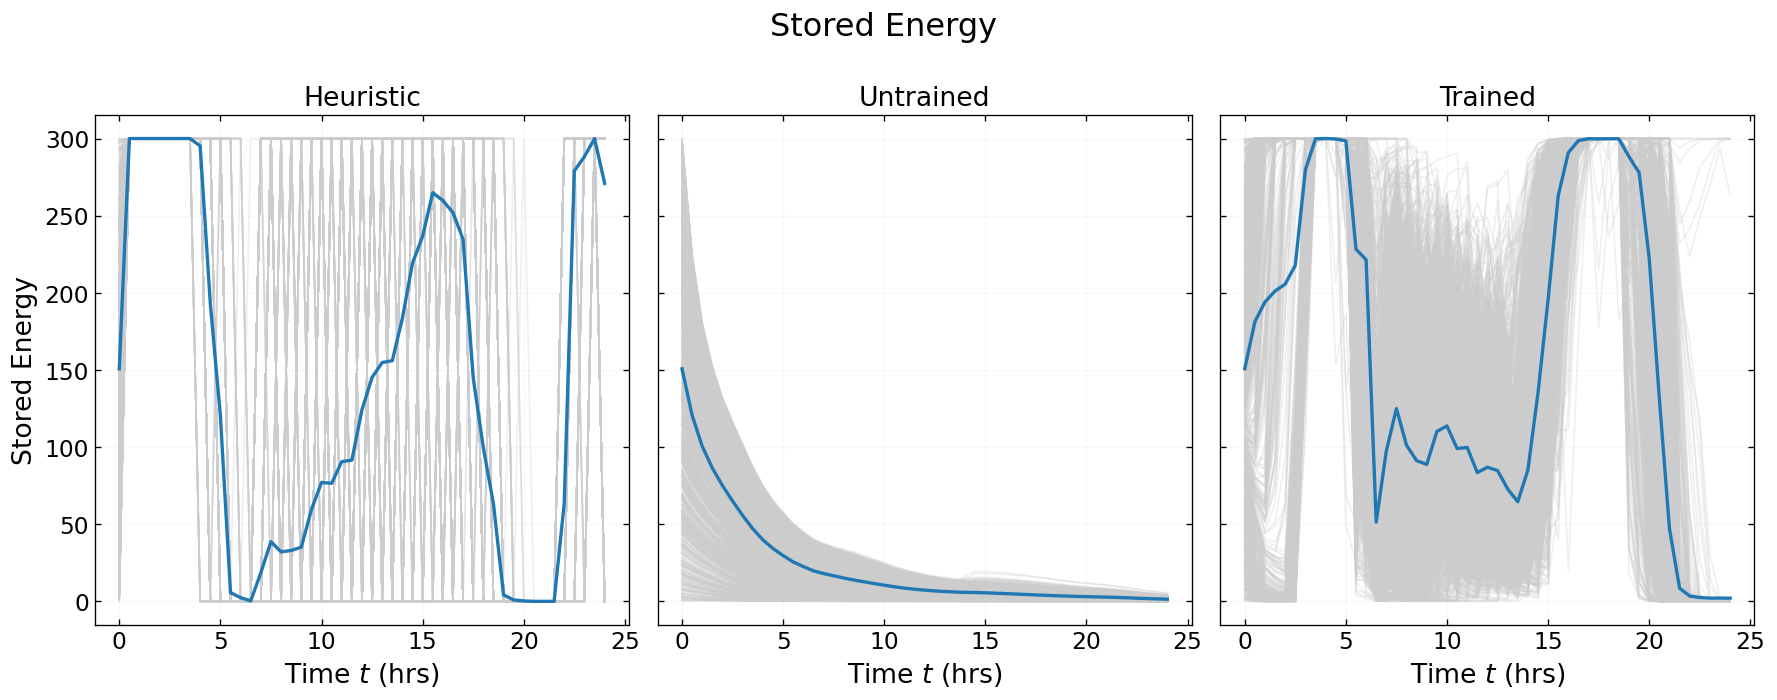

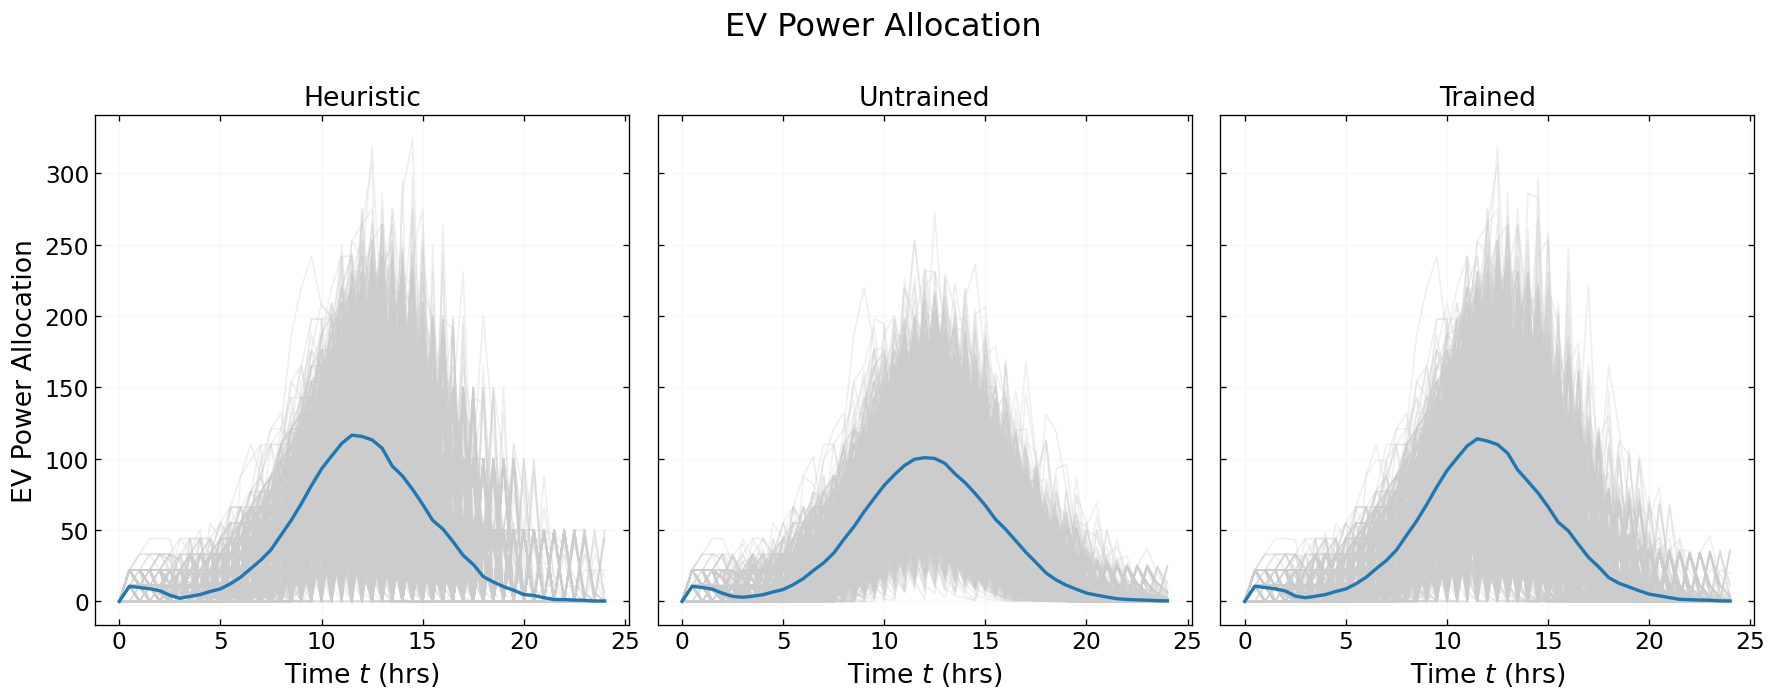

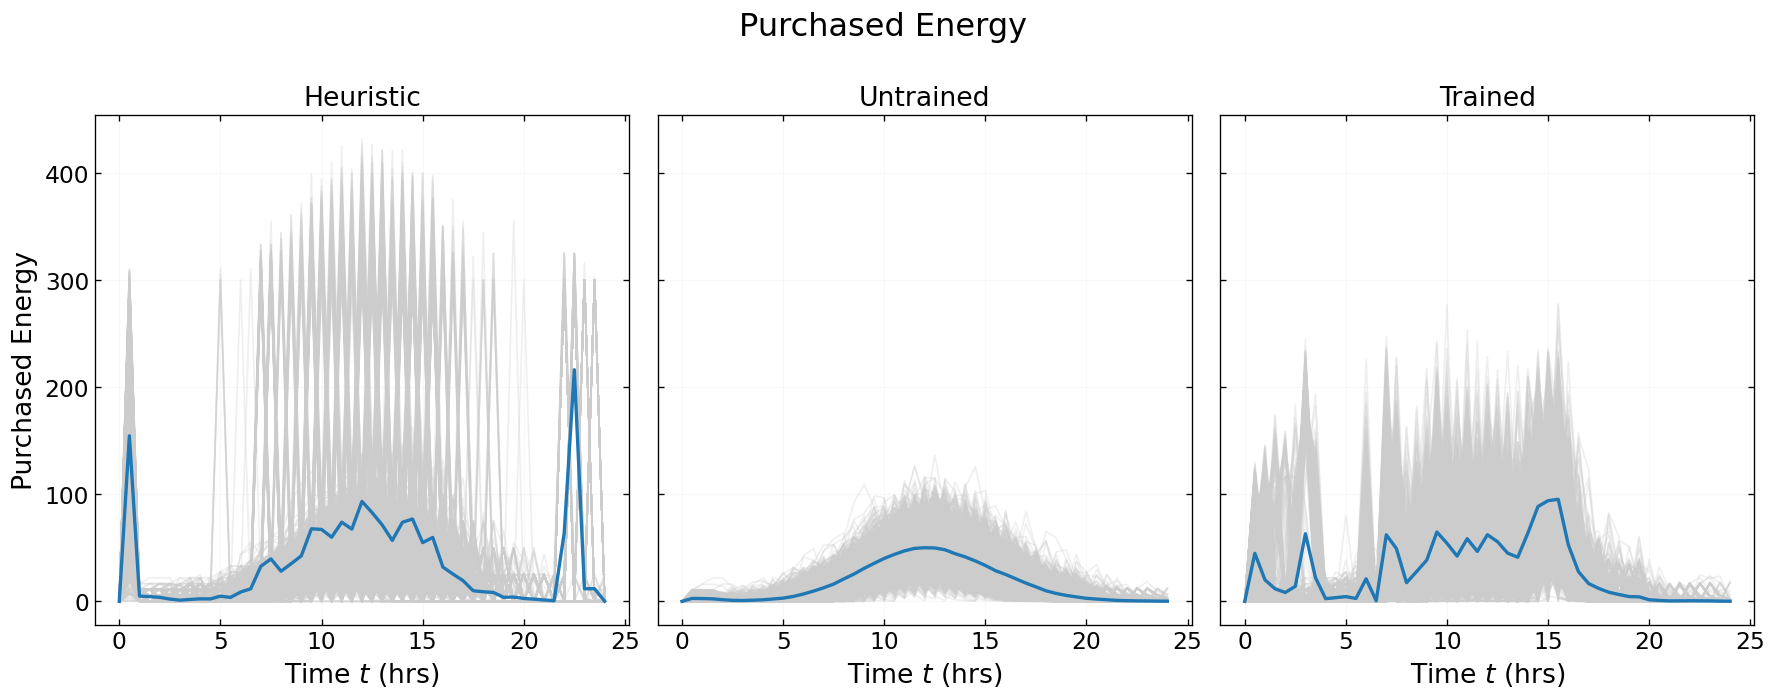

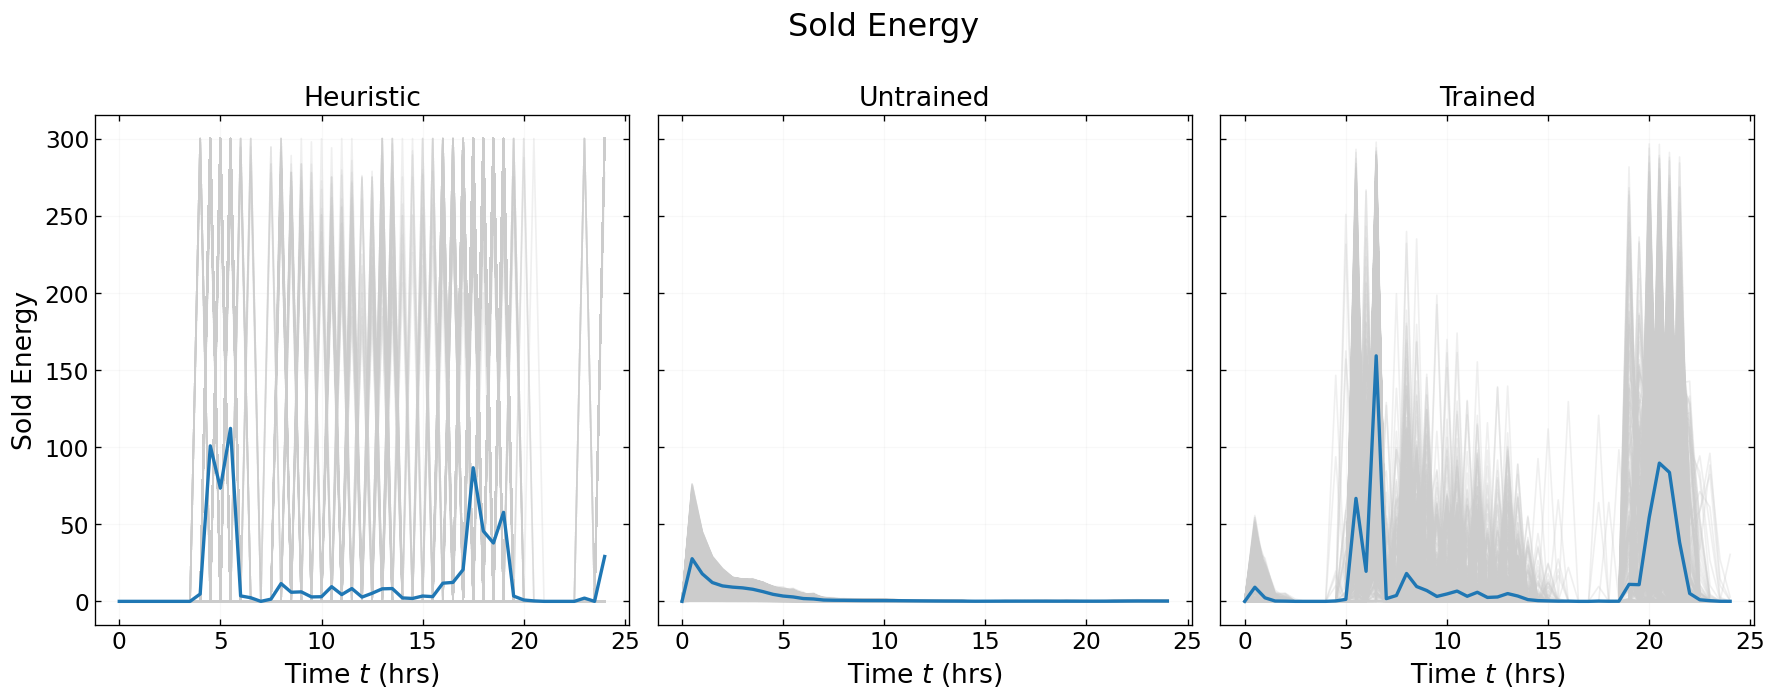

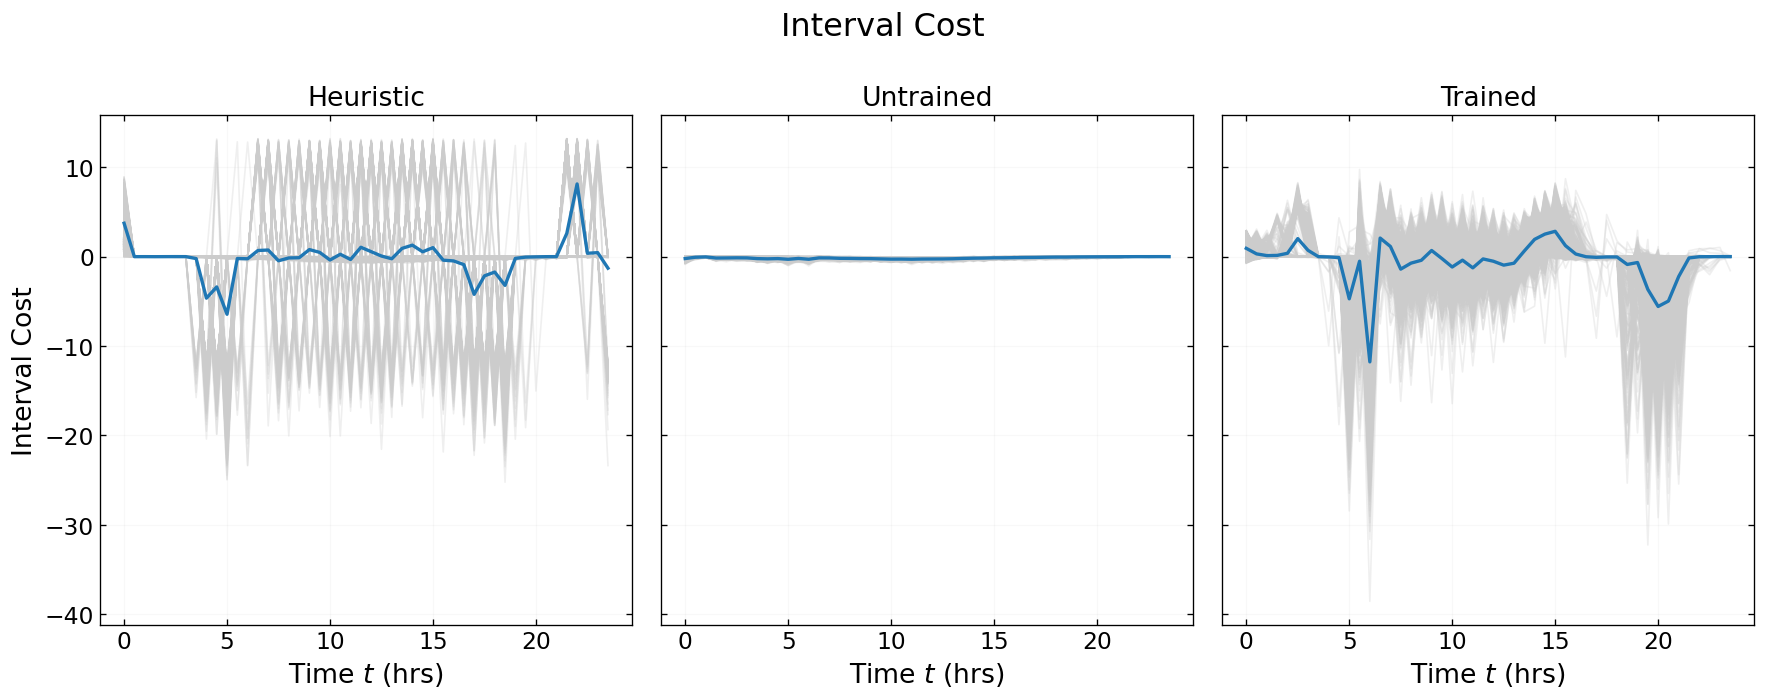

In [45]:
plot_variable_across_policies(
    results,
    "E",
    "Stored Energy",
    "../figures/policy_comparison/stored_energy.pdf"
)

plot_variable_across_policies(
    results,
    "q",
    "EV Power Allocation",
    "../figures/policy_comparison/ev_power_allocation.pdf"
)

plot_variable_across_policies(
    results,
    "Ub",
    "Purchased Energy",
    "../figures/policy_comparison/purchased_energy.pdf"
)

plot_variable_across_policies(
    results,
    "Us",
    "Sold Energy",
    "../figures/policy_comparison/sold_energy.pdf"
)

plot_variable_across_policies(
    results,
    "c",
    "Interval Cost",
    "../figures/policy_comparison/interval_cost.pdf"
)

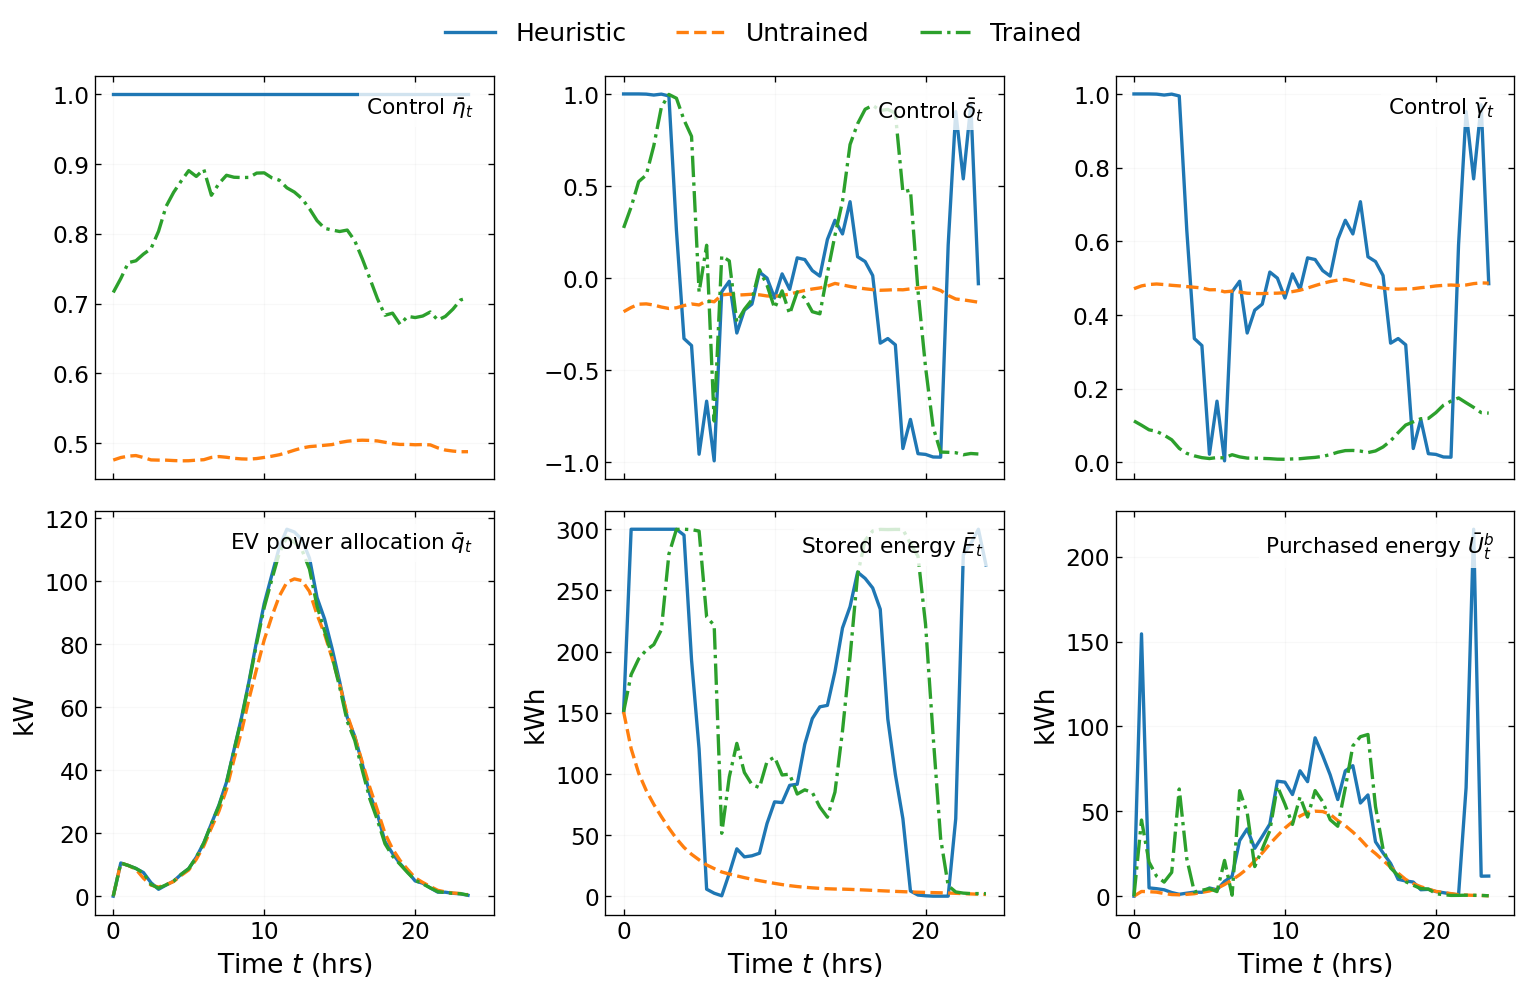

In [40]:
plot_controls_summary(
    results,
    "../figures/policy_comparison/controls_summary.pdf"
)